## Python For Machine Learning Fall 2025
---
# Gated RNNs (LSTM & GRU)

In [ ]:
# Install necessary libraries for visualization and data (if not installed already)
!pip install torchviz torchdata portalocker torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.0 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import urllib.request
import zipfile

# Set random seed for reproducibility
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. The Problem with Vanilla RNNs

Our experiment using a Recurrent Neural Network for sentiment analysis on SST-2 data failed, despite the theoretical viability of the model. Why do you believe this occurred?


Simple RNNs suffer from the **vanishing gradient problem**. When backpropagating through time, the gradients (used for learning) can shrink exponentially. This means the network struggles to learn long-range dependencies—it effectively "forgets" what it saw many time steps ago.

Below, we visualize the gradient back propgation when training a simple RNN on the SST-2 (Stanford Sentiment Treebank) dataset.

Download the SST-2 dataset.

In [ ]:
def download_sst2():
    url = "https://dl.fbaipublicfiles.com/glue/data/SST-2.zip"
    if not os.path.exists("SST-2.zip"):
        print("Downloading SST-2 Dataset...")
        urllib.request.urlretrieve(url, "SST-2.zip")
    if not os.path.exists("SST-2"):
        with zipfile.ZipFile("SST-2.zip", 'r') as zip_ref:
            zip_ref.extractall(".")
    return pd.read_csv("SST-2/train.tsv", sep='\t')

df = download_sst2()
sentences = df['sentence'].values
labels = df['label'].values

Preprocessing.

In [ ]:
vocab = {"<PAD>": 0, "<UNK>": 1}

def tokenize(text):
    return text.lower().split()

for sentence in sentences:
    for word in tokenize(sentence):
        if word not in vocab:
            vocab[word] = len(vocab)

print(f"Vocabulary Size: {len(vocab)}")

Vocabulary Size: 14818


Here we create a long sequence sample to demonstrate vanishing gradient. We concatenate multiple sentences to force a long dependency

In [ ]:
def encode_sentence(text, max_len=50):
    tokens = tokenize(text)
    encoded = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    if len(encoded) < max_len:
        encoded += [vocab["<PAD>"]] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    return encoded

long_text = " ".join(sentences[:20])
input_indices = torch.tensor([encode_sentence(long_text, max_len=200)], dtype=torch.long).to(device)

Define a simple RNN structure and initialize an instance.

In [ ]:
class SimpleRNNInspect(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn_cell = nn.RNNCell(embed_dim, hidden_dim)
        self.hidden_dim = hidden_dim

    def forward(self, x):
        embeddings = self.embedding(x)
        h = torch.zeros(x.size(0), self.hidden_dim).to(x.device)

        hidden_states = []
        for t in range(x.size(1)):
            input_t = embeddings[:, t, :]
            h = self.rnn_cell(input_t, h)
            h.retain_grad() # keep grad for visualization
            hidden_states.append(h)

        return hidden_states

model_vanilla = SimpleRNNInspect(len(vocab), 64, 64).to(device)


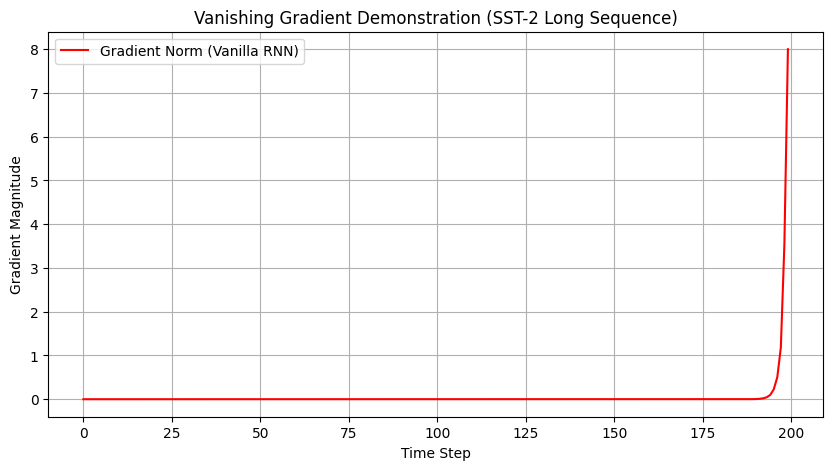

Notice how the gradient magnitude drops significantly as we go back in time (left side of the graph).


In [ ]:

# Forward pass
hidden_states = model_vanilla(input_indices)
final_state = hidden_states[-1]

# Backward pass (dummy loss)
loss = final_state.sum()
loss.backward()

# Extract gradient norms
grads = [h.grad.norm().item() for h in hidden_states]

plt.figure(figsize=(10, 5))
plt.plot(grads, label="Gradient Norm (Vanilla RNN)", color='red')
plt.title("Vanishing Gradient Demonstration (SST-2 Long Sequence)")
plt.xlabel("Time Step")
plt.ylabel("Gradient Magnitude")
plt.legend()
plt.grid(True)
plt.show()

print("Notice how the gradient magnitude drops significantly as we go back in time (left side of the graph).")

# 2. Gated Architectures

The core concept of gated architectures in LSTMs and GRUs is the use of learnable mechanisms that act as valves to regulate the flow of information, rather than simply processing every input equally. These gates typically employ sigmoid activation functions which output a value between 0 and 1, acting as multiplicative filters against the data stream. A value of 0 represents a closed gate (completely blocking or "forgetting" information), while a value of 1 represents an open gate (allowing information to pass through or be "remembered"). By training these gates to selectively shield the internal memory from irrelevant noise while allowing important long-term dependencies to pass through, the network solves the vanishing gradient problem and maintains context over long sequences.


## 2.1 The Core Idea: Selective Memory

To understand why these gates are so powerful, think about how your own brain processes memory.

Imagine you are sitting in a busy coffee shop. You hear the coffee machine hissing, people chatting at the next table, and the door opening and closing. Suddenly, your friend sitting across from you starts telling you important news.

1.  **Filtering (The Forget Gate):** Your brain automatically "tunes out" (forgets) the background noise of the coffee machine because it's irrelevant to your current conversation.
2.  **Focusing (The Input Gate):** Your brain sharply focuses on your friend's words, committing the important details (dates, names) to your short-term memory.
3.  **Recalling (The Output Gate):** Later, when someone asks "How is your friend?", your brain retrieves just that specific conversation from memory to form your answer, ignoring the fact that you also saw a dog walk by the window at the same time.

Gated RNNs operate on this exact principle. Instead of blindly processing every single input with equal weight (like a Vanilla RNN), they learn to **ignore** noise, **keep** critical signals, and **retrieve** context only when needed. This allows them to handle long sequences where the critical clue might be hundreds of steps away from the answer.

## 2.2 LSTM (Long Short-Term Memory)

Long Short-Term Memory (LSTM) networks are a specialized evolution of Recurrent Neural Networks (RNNs) explicitly designed to learn long-term dependencies and mitigate the vanishing gradient problem. The architectural core of an LSTM is the cell state, often visualized as a conveyor belt that allows information to flow unchanged through the network sequence. This flow is strictly regulated by three distinct structures called gates: the forget gate (which removes irrelevant history), the input gate (which updates the cell with new data), and the output gate (which determines the next hidden state). By utilizing sigmoid and tanh activation functions within these gates, LSTMs can selectively memorize or discard information, making them exceptionally powerful for processing complex sequential data like time series, speech, and text.

## 2.3 LSTM in Practice (PyTorch)

In PyTorch, we use `nn.LSTM` to implement LSTM easily. However, here we implement a LSTM unit from scratch and compare it with the `nn.LSTM`.

### 2.3.1 The Mathematical Blueprint

For a given time step $t$, input $x_t$, and previous hidden state $h_{t-1}$:

1. Forget Gate:
$$
f_t = \sigma(W_f \cdot [h_{t-1}, x] + b_f)
$$

2.  Input Gate:
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

3.  Candidate Cell:
$$
\widetilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] )
$$

4.  Output Gate:
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

5.  Cell State Update:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

6.  Hidden State Update:
$$h_t = o_t \odot \tanh(C_t)$$

*Where $\sigma$ is the sigmoid function, and $\odot$ denotes element-wise multiplication.*

### 2.3.2 LSTM Implementation

Import the necessary libaries.

In [ ]:
import torch
import torch.nn as nn
import math

Define a `CustomLSTM` according to our mathematical blueprint/

In [ ]:
class CustomLSTM(nn.Module):
    def __init__(self, input_sz, hidden_sz):
        super().__init__()
        self.input_sz = input_sz
        self.hidden_sz = hidden_sz
        # Linear layer for (Input + Hidden) -> (4 * Hidden)
        # Note: PyTorch stores weights in order: Input, Forget, Cell(Candidate), Output
        self.W = nn.Linear(input_sz + hidden_sz, 4 * hidden_sz)

    def forward(self, x, init_states=None):
        batch_sz, seq_len, _ = x.size()

        if init_states is None:
            h_t, c_t = (torch.zeros(batch_sz, self.hidden_sz).to(x.device),
                        torch.zeros(batch_sz, self.hidden_sz).to(x.device))
        else:
            h_t, c_t = init_states

        hidden_seq = []

        for t in range(seq_len):
            x_t = x[:, t, :]

            # Concatenate input and hidden state
            combined = torch.cat((x_t, h_t), dim=1)

            # Compute gates
            gates = self.W(combined)

            # Split: Input(i), Forget(f), Candidate(g), Output(o)
            # PyTorch standard order is IFGO
            head_i, head_f, head_g, head_o = gates.chunk(4, dim=1)

            i_t = torch.sigmoid(head_i)
            f_t = torch.sigmoid(head_f)
            g_t = torch.tanh(head_g)
            o_t = torch.sigmoid(head_o)

            c_t = (f_t * c_t) + (i_t * g_t)
            h_t = o_t * torch.tanh(c_t)

            hidden_seq.append(h_t.unsqueeze(1))

        hidden_seq = torch.cat(hidden_seq, dim=1)
        return hidden_seq, (h_t, c_t)

Declare hyperparameters.

In [ ]:
INPUT_SIZE = 10
HIDDEN_SIZE = 20
BATCH_SIZE = 5
SEQ_LEN = 100

print(f"Input Size: {INPUT_SIZE}, Hidden Size: {HIDDEN_SIZE}")
print(f"Batch: {BATCH_SIZE}, Sequence Length: {SEQ_LEN}\n")

--- Configuration ---
Input Size: 10, Hidden Size: 20
Batch: 5, Sequence Length: 100



Now let's calculate the difference between the `CustomLSTM` and `nn.LSTM`.

In [ ]:
# batch_first=True makes input shape (Batch, Seq, Feature)
official_lstm = nn.LSTM(INPUT_SIZE, HIDDEN_SIZE, batch_first=True)

# B. Initialize Custom LSTM
custom_lstm = CustomLSTM(INPUT_SIZE, HIDDEN_SIZE)

We must copy weights from Official -> Custom to ensure they compute the same thing. Transpose is needed because nn.Linear expects (Out, In) but logic might differ slightly. We concatenate Official IH (weight_ih_l0) and HH (weight_i=hh_l0) weights along dimension 1 to match our [x, h] logic. Official LSTM has two biases (bias_ih_l0 and bias_hh_l0) that are added together

In [ ]:
with torch.no_grad():

    combined_weight = torch.cat((official_lstm.weight_ih_l0, official_lstm.weight_hh_l0), dim=1)
    custom_lstm.W.weight.copy_(combined_weight)

    combined_bias = official_lstm.bias_ih_l0 + official_lstm.bias_hh_l0
    custom_lstm.W.bias.copy_(combined_bias)

print("Weights synchronized successfully.\n")

Weights synchronized successfully.



Now we can run the forward passes and measure the difference.

In [ ]:
x = torch.randn(BATCH_SIZE, SEQ_LEN, INPUT_SIZE)

# Run Official
out_official, (h_official, c_official) = official_lstm(x)

# Run Custom
out_custom, (h_custom, c_custom) = custom_lstm(x)

diff_output = (out_official - out_custom).abs().max().item()
diff_hidden = (h_official - h_custom).abs().max().item()
diff_cell = (c_official - c_custom).abs().max().item()

print(f"--- Results ---")
print(f"Max difference in Outputs:      {diff_output:.8f}")
print(f"Max difference in Hidden State: {diff_hidden:.8f}")
print(f"Max difference in Cell State:   {diff_cell:.8f}")

--- Results ---
Max difference in Outputs:      0.00000015
Max difference in Hidden State: 0.00000009
Max difference in Cell State:   0.00000012


## 2.4 Gated Recurrent Unit (GRU)

Cho et al. developed the Gated Recurrent Unit in 2014 with the philosophy of maximizing simplicity while maintaining memory. If one considers the LSTM a precise but complex three-valve system, the GRU represents an industrially optimized two-valve system.

### 2.4.1 GRU Mathematical Blueprint

For a given time step $t$, input $x_t$, and previous hidden state $h_{t-1}$:

1. Reset Gate ($r_t$): Determines how much of the past information to forget.
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)$$

2. Update Gate ($z_t$): Determines the balance between keeping the old state and adding new information.
$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)$$

3. Candidate Hidden State ($\widetilde{h}_t$): Calculates the new candidate memory. Note how the Reset Gate ($r_t$) is applied to the previous hidden state here.
$$\widetilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h)$$

4. Final Hidden State ($h_t$): Performs linear interpolation between the old state and the new candidate.
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \widetilde{h}_t$$

*Where:*
* $\sigma$: Sigmoid function (outputs 0 to 1)
* $\odot$: Element-wise multiplication
* $z_t$: The "mixing" factor. If $z_t \approx 1$, we mostly use the new info. If $z_t \approx 0$, we keep the old info.

### 2.4.2 GRU Implementation

Define a `CustomGRU` model from scratch. In an LSTM, it is possible to concatenate the input and hidden states into a single layer. However, for a GRU, it is cleaner to separate the input weights from the hidden weights because the Reset Gate applies strictly to the hidden component.

In [ ]:
class CustomGRU(nn.Module):
    def __init__(self, input_sz, hidden_sz):
        super().__init__()
        self.input_sz = input_sz
        self.hidden_sz = hidden_sz

        # Input Weights: Projects x -> (Reset, Update, New)
        self.weight_ih = nn.Linear(input_sz, 3 * hidden_sz)

        # Hidden Weights: Projects h -> (Reset, Update, New)
        self.weight_hh = nn.Linear(hidden_sz, 3 * hidden_sz)

    def forward(self, x, init_states=None):
        """
        x shape: (batch, seq_len, input_sz)
        """
        batch_sz, seq_len, _ = x.size()

        if init_states is None:
            h_t = torch.zeros(batch_sz, self.hidden_sz).to(x.device)
        else:
            h_t = init_states

        hidden_seq = []

        for t in range(seq_len):
            x_t = x[:, t, :]

            # 1. Compute all Input projections (x_t * W_ih)
            # Result shape: (batch, 3 * hidden_sz)
            x_gate = self.weight_ih(x_t)

            # 2. Compute all Hidden projections (h_{t-1} * W_hh)
            # Result shape: (batch, 3 * hidden_sz)
            h_gate = self.weight_hh(h_t)

            # Split them into specific gates: Reset(r), Update(z), New/Candidate(n)
            # PyTorch order is: Reset, Update, New
            x_r, x_z, x_n = x_gate.chunk(3, dim=1)
            h_r, h_z, h_n = h_gate.chunk(3, dim=1)

            # --- Gate Calculations ---

            # Reset Gate
            r_t = torch.sigmoid(x_r + h_r)

            # Update Gate
            z_t = torch.sigmoid(x_z + h_z)

            # Candidate Hidden State (n_t)
            # Note: PyTorch applies the Reset gate (r_t) to the HIDDEN projection (h_n)
            n_t = torch.tanh(x_n + (r_t * h_n))

            # --- Final State Update ---
            # PyTorch Logic: h_t = (1 - z) * n + z * h_old
            # (This implies z=1 means "Keep Old", z=0 means "Update New")
            h_t = (1 - z_t) * n_t + (z_t * h_t)

            hidden_seq.append(h_t.unsqueeze(1))

        hidden_seq = torch.cat(hidden_seq, dim=1)
        return hidden_seq, h_t

Declare hyperparameters and initialize the model instances.

In [ ]:
INPUT_SIZE = 10
HIDDEN_SIZE = 20
BATCH_SIZE = 5
SEQ_LEN = 100

print(f"--- GRU Configuration ---")
print(f"Input: {INPUT_SIZE}, Hidden: {HIDDEN_SIZE}, Batch: {BATCH_SIZE}")

--- GRU Configuration ---
Input: 10, Hidden: 20, Batch: 5


In [ ]:
# A. Official PyTorch GRU
official_gru = nn.GRU(INPUT_SIZE, HIDDEN_SIZE, batch_first=True)

# B. Custom GRU
custom_gru = CustomGRU(INPUT_SIZE, HIDDEN_SIZE)

Synchronize Weights.

In [ ]:
with torch.no_grad():
    # Copy Input-to-Hidden weights
    custom_gru.weight_ih.weight.copy_(official_gru.weight_ih_l0)
    custom_gru.weight_ih.bias.copy_(official_gru.bias_ih_l0)

    # Copy Hidden-to-Hidden weights
    custom_gru.weight_hh.weight.copy_(official_gru.weight_hh_l0)
    custom_gru.weight_hh.bias.copy_(official_gru.bias_hh_l0)

Calculate the forward pass and compare the output.

In [ ]:
x = torch.randn(BATCH_SIZE, SEQ_LEN, INPUT_SIZE)

out_official, h_official = official_gru(x)
out_custom, h_custom = custom_gru(x)

# E. Measure Difference
diff = (out_official - out_custom).abs().max().item()

print(f"Max difference: {diff:.8f}")

Max difference: 0.00000012


# 3. LSTM vs. GRU

When choosing between LSTM and GRU, consider the following tradeoffs:

| Feature | LSTM (Long Short-Term Memory) | GRU (Gated Recurrent Unit) |
| :--- | :--- | :--- |
| **Complexity** | High (3 Gates: Input, Forget, Output) | Medium (2 Gates: Update, Reset) |
| **Memory** | Maintains separate Cell State ($C_t$) and Hidden State ($h_t$) | Merges them into a single Hidden State ($h_t$) |
| **Parameters** | More parameters (slower to train) | Fewer parameters (faster to train) |
| **Dataset Size** | Better for large datasets where detail is key | Often better for smaller datasets (less overfitting) |
| **Long-Term Memory** | Theoretically capable of longer memories due to separate Cell State | Very capable, but theoretically slightly less robust for extremely long sequences |

**Verdict:** Start with LSTM for complex tasks. Switch to GRU if you need faster training or have less data.

# 4. Comparitive Experiment: LSTM vs. GRU on SST-2

he simple RNN failed to converge effectively due to the vanishing gradient problem inherent in processing long sequences. To address this, we can use LSTM and GRU architectures. The gating mechanisms will regulate the flow of information, allow the network to retain long-term dependencies.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer

Load the SST-2 dataset and a pre-trained tokenizer, `bert-base-uncased`.

In [ ]:
dataset = load_dataset("glue", "sst2")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Apply the tokenizer and convert to PyTorch tensors.

In [ ]:
def tokenize_function(examples):
    # This will pad all sentences to the same length (padding="max_length")
    # and truncate long ones (truncation=True)
    return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=64)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Dataset splits:")
print(tokenized_datasets)
print("\nExample from training data:")
print(tokenized_datasets["train"][0])

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

Example from training data:
{'label': tensor(0), 'input_ids': tensor([  101,  5342,  2047,  3595,  8496,  2013,  1996, 18643,  3197,   102,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,   

Create dataloaders.

In [ ]:
BATCH_SIZE = 64

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True,
    batch_size=BATCH_SIZE
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"],
    batch_size=BATCH_SIZE
)

# Let's check one batch
batch = next(iter(train_dataloader))
print("\nShape of one batch (input_ids):")
print(batch['input_ids'].shape)
print("(Batch Size, Sequence Length)")


Shape of one batch (input_ids):
torch.Size([64, 64])
(Batch Size, Sequence Length)


Define three models, RNN, LSTM, and GRU.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        output, (hidden, cell) = self.lstm(embedded)
        prediction = self.fc(hidden.squeeze(0))
        return prediction

In [ ]:
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        output, hidden = self.gru(embedded)
        prediction = self.fc(hidden.squeeze(0))
        return prediction

In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        output, hidden = self.rnn(embedded)
        return self.fc(hidden.squeeze(0))

Define the training process.

In [ ]:
def train_and_track(model, dataloader_train, dataloader_val, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters())

    history = {
        'train_acc': [],
        'val_acc': [],
        'train_loss': [],
        'val_loss': []
    }

    print(f"Training {type(model).__name__}...")

    for epoch in range(epochs):
        # Train
        model.train()
        train_correct = 0
        train_total = 0
        train_loss_sum = 0

        for batch in dataloader_train:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)

            preds = model(input_ids).squeeze(1)
            loss = criterion(preds, labels.float())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Metrics
            rounded_preds = torch.round(torch.sigmoid(preds))
            train_correct += (rounded_preds == labels).sum().item()
            train_total += len(labels)
            train_loss_sum += loss.item()

        history['train_acc'].append(train_correct / train_total)
        history['train_loss'].append(train_loss_sum / len(dataloader_train))

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss_sum = 0

        with torch.no_grad():
            for batch in dataloader_val:
                input_ids = batch['input_ids'].to(device)
                labels = batch['label'].to(device)

                preds = model(input_ids).squeeze(1)
                loss = criterion(preds, labels.float())

                rounded_preds = torch.round(torch.sigmoid(preds))
                val_correct += (rounded_preds == labels).sum().item()
                val_total += len(labels)
                val_loss_sum += loss.item()

        history['val_acc'].append(val_correct / val_total)
        history['val_loss'].append(val_loss_sum / len(dataloader_val))

        print(f"  Epoch {epoch+1}/{epochs} | Val Acc: {history['val_acc'][-1]:.4f}")

    return history

Define hyperparameters and initialize the models.

In [ ]:
# Hyperparameters
VOCAB_SIZE = tokenizer.vocab_size
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 1
N_EPOCHS = 5

# Initialize models
rnn_model = SentimentRNN(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM)
lstm_model = SentimentLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM)
gru_model = SentimentGRU(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM)

Train the models.

In [ ]:
rnn_history = train_and_track(rnn_model, train_dataloader, val_dataloader, N_EPOCHS)
lstm_history = train_and_track(lstm_model, train_dataloader, val_dataloader, N_EPOCHS)
gru_history = train_and_track(gru_model, train_dataloader, val_dataloader, N_EPOCHS)

Training SentimentRNN...
  Epoch 1/5 | Val Acc: 0.5092
  Epoch 2/5 | Val Acc: 0.5092
  Epoch 3/5 | Val Acc: 0.5092
  Epoch 4/5 | Val Acc: 0.5092
  Epoch 5/5 | Val Acc: 0.5092
Training SentimentLSTM...
  Epoch 1/5 | Val Acc: 0.5092
  Epoch 2/5 | Val Acc: 0.5092
  Epoch 3/5 | Val Acc: 0.6892
  Epoch 4/5 | Val Acc: 0.8268
  Epoch 5/5 | Val Acc: 0.8337
Training SentimentGRU...
  Epoch 1/5 | Val Acc: 0.8096
  Epoch 2/5 | Val Acc: 0.8268
  Epoch 3/5 | Val Acc: 0.8291
  Epoch 4/5 | Val Acc: 0.8326
  Epoch 5/5 | Val Acc: 0.8303


Visualize the training history.

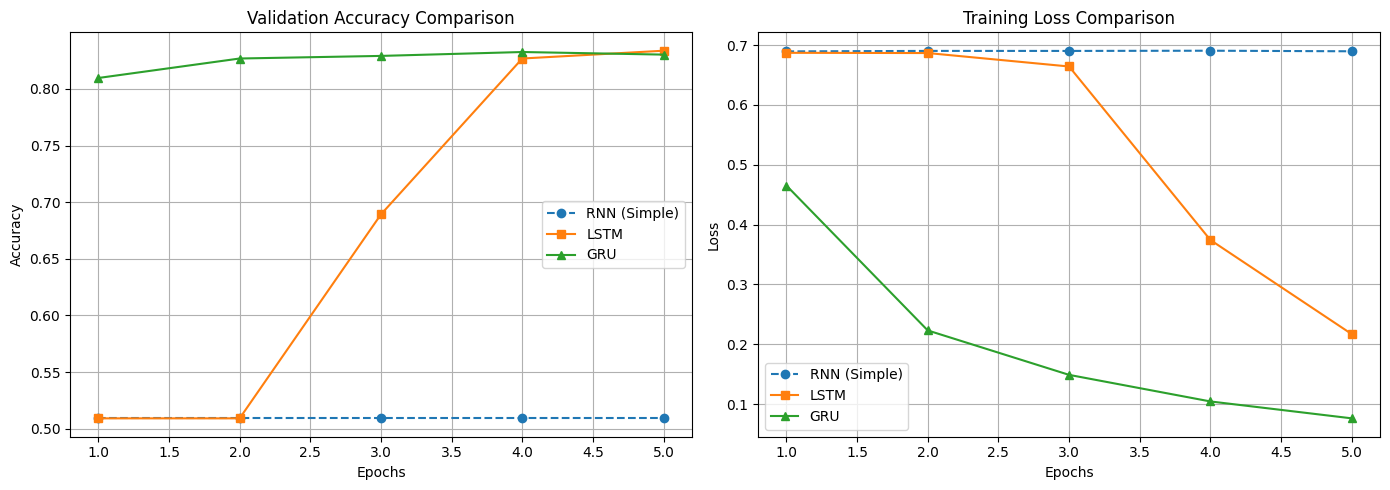

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, N_EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, rnn_history['val_acc'], label='RNN (Simple)', linestyle='--', marker='o')
plt.plot(epochs_range, lstm_history['val_acc'], label='LSTM', marker='s')
plt.plot(epochs_range, gru_history['val_acc'], label='GRU', marker='^')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, rnn_history['train_loss'], label='RNN (Simple)', linestyle='--', marker='o')
plt.plot(epochs_range, lstm_history['train_loss'], label='LSTM', marker='s')
plt.plot(epochs_range, gru_history['train_loss'], label='GRU', marker='^')

plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()